In [1]:
import eurostat
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pmdarima as pm

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

In [105]:
import eurostat
import pandas as pd
import os

def fetch_and_clean_eurostat(dataset_code, filter_params, col_name):
    df_raw = eurostat.get_data_df(dataset_code, filter_pars=filter_params)
    time_col = [col for col in df_raw.columns if 'TIME_PERIOD' in col][0]
    id_vars = df_raw.columns[:df_raw.columns.get_loc(time_col)+1].tolist()
    df_melted = df_raw.melt(id_vars=id_vars, var_name='date', value_name=col_name)
    df_melted['date'] = pd.to_datetime(df_melted['date'].str.replace('-M', '-'), format='%Y-%m')
    df_clean = df_melted[['date', col_name]].copy()
    df_clean[col_name] = pd.to_numeric(df_clean[col_name], errors='coerce')
    df_clean = df_clean[df_clean['date'] >= '2010-01-01']
    df_clean = df_clean.dropna()
    df_clean = df_clean.drop_duplicates(subset=['date'])
    return df_clean

# 1. Consumul de Energie
params_consum = {'geo': ['RO'], 'nrg_bal': ['AIM'], 'siec': ['E7000'], 'unit': ['GWH']}
df_consum = fetch_and_clean_eurostat('nrg_cb_em', params_consum, 'Consum_Energie_GWh')

# 2. Productia Industriala
params_industrie = {'geo': ['RO'], 'nace_r2': ['B-D'], 's_adj': ['NSA'], 'unit': ['I21']}
df_industrie = fetch_and_clean_eurostat('sts_inpr_m', params_industrie, 'Productie_Industriala_Idx')

# 3. Inflatie Energie (Sudura istoricului pe baza I15)
params_inflatie_old = {'geo': ['RO'], 'coicop': ['CP0451'], 'unit': ['I15']}
df_inflatie_old = fetch_and_clean_eurostat('prc_hicp_midx', params_inflatie_old, 'Inflatie_Energie_Ipc')

params_inflatie_new = {'geo': ['RO'], 'coicop18': ['CP04510'], 'unit': ['I15']}
df_inflatie_new = fetch_and_clean_eurostat('prc_hicp_minr', params_inflatie_new, 'Inflatie_Energie_Ipc')

df_inflatie = pd.concat([df_inflatie_old, df_inflatie_new])
df_inflatie = df_inflatie.drop_duplicates(subset=['date'], keep='last')

# Unificare Finala
df = pd.merge(df_consum, df_industrie, on='date', how='inner')
df = pd.merge(df, df_inflatie, on='date', how='inner')
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

# Salvare in folderul corect
output_path = os.path.join('..', 'data', 'baza_date_proiect.xlsx')
df.to_excel(output_path)

print("Shape final:", df.shape)
print("Interval date:", df.index.min().date(), "până la", df.index.max().date())
print("\nPrimele 5 inregistrari:")
df.head(5)

Shape final: (195, 3)
Interval date: 2010-01-01 până la 2026-03-01

Primele 5 inregistrari:


,Consum_Energie_GWh,Productie_Industriala_Idx,Inflatie_Energie_Ipc
date,,,
2010-01-01,4802.0,60.6,72.99
2010-02-01,4496.0,63.7,72.99
2010-03-01,4606.0,73.5,72.99
2010-04-01,4032.0,67.8,72.99
2010-05-01,3967.0,70.1,72.99


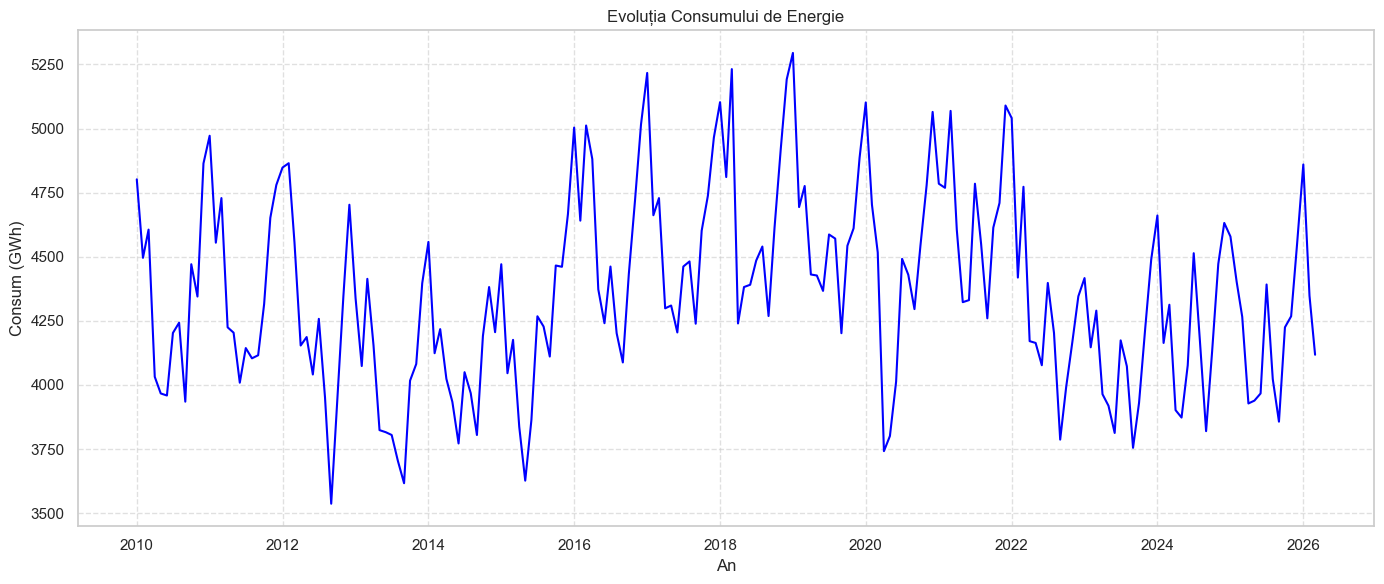

In [ ]:
df.sort_index(inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)

plt.title('Evolutia Consumului de Energie')
plt.xlabel('An')
plt.ylabel('Consum (GWh)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [118]:
import pandas as pd

# Calculul statisticilor descriptive standard
stats = df['Consum_Energie_GWh'].describe()

# Adaugarea indicatorilor de forma a distributiei pentru analiza econometrica
stats['skewness'] = df['Consum_Energie_GWh'].skew()
stats['kurtosis'] = df['Consum_Energie_GWh'].kurtosis()

print("--- Statistici descriptive: Consum Energie ---")
print(stats)

--- Statistici descriptive: Consum Energie ---
count        195.000000
mean        4358.574359
std          367.837801
min         3537.000000
25%         4096.000000
50%         4331.000000
75%         4606.000000
max         5295.000000
skewness       0.288032
kurtosis      -0.410495
Name: Consum_Energie_GWh, dtype: float64


In [4]:
#Train-test split

train = df['Consum_Energie_GWh'][:-24]
test = df['Consum_Energie_GWh'][-24:]

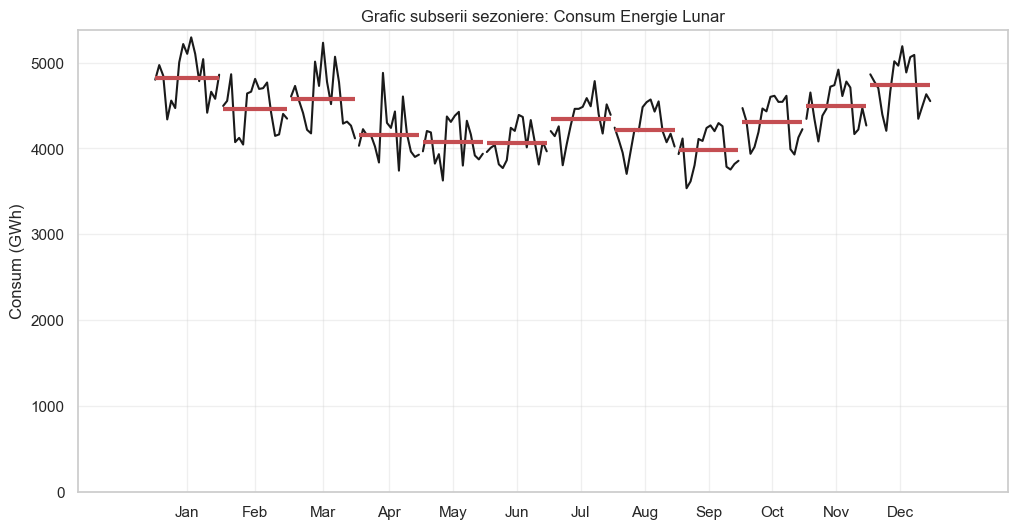

In [106]:
from statsmodels.graphics.tsaplots import month_plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
month_plot(df['Consum_Energie_GWh'].dropna(), ax=ax)

# Aici e magia: forțăm axa Y să înceapă de la 0
ax.set_ylim(bottom=0)

plt.title('Grafic subserii sezoniere: Consum Energie Lunar')
plt.ylabel('Consum (GWh)')
plt.grid(True, alpha=0.3)
plt.show()

In [107]:
import pmdarima as pm
# Dacă rezultatul este 0 -> Sezonalitate stabila (H0 acceptata)
# Dacă rezultatul este 1 -> Sezonalitate instabila (H1 acceptata)

rezultat_ch = pm.arima.nsdiffs(df['Consum_Energie_GWh'].dropna(), m=12, test='ch')

print("--- Rezultat Test Canova-Hansen ---")
print(f"Valoarea returnata: {rezultat_ch}")

if rezultat_ch > 0:
    print("Concluzie: Tiparul sezonier este INSTABIL (respinge H0).")
else:
    print("Concluzie: Tiparul sezonier este STABIL (acceptă H0).")

--- Rezultat Test Canova-Hansen ---
Valoarea returnata: 0
Concluzie: Tiparul sezonier este STABIL (acceptă H0).


In [108]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

def check_stationarity(series, name):
    print(f"--- Teste de Stationaritate pentru {name} ---")

    # ADF Test
    adf_res = adfuller(series)
    print(f"ADF p-value: {adf_res[1]:.4f}")

    # KPSS Test
    kpss_res = kpss(series, regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_res[1]:.4f}")

    # Logica de decizie
    # ADF - vrem p < 0.05 pentru a respinge H0 (stationara)
    # KPSS (H0: seria este stationara) - vrem p > 0.05 pentru a accepta H0 (stationara)
    
    if adf_res[1] < 0.05 and kpss_res[1] > 0.05:
        print("Concluzie: Seria este probabil stationara.\n")
    else:
        print("Concluzie: Seria este probabil nestationara (necesita diferentiere).\n")

# Aici folosim coloana ta specifica
check_stationarity(df['Consum_Energie_GWh'], "Consum Energie")

--- Teste de Stationaritate pentru Consum Energie ---
ADF p-value: 0.2492
KPSS p-value: 0.1000
Concluzie: Seria este probabil nestationara (necesita diferentiere).



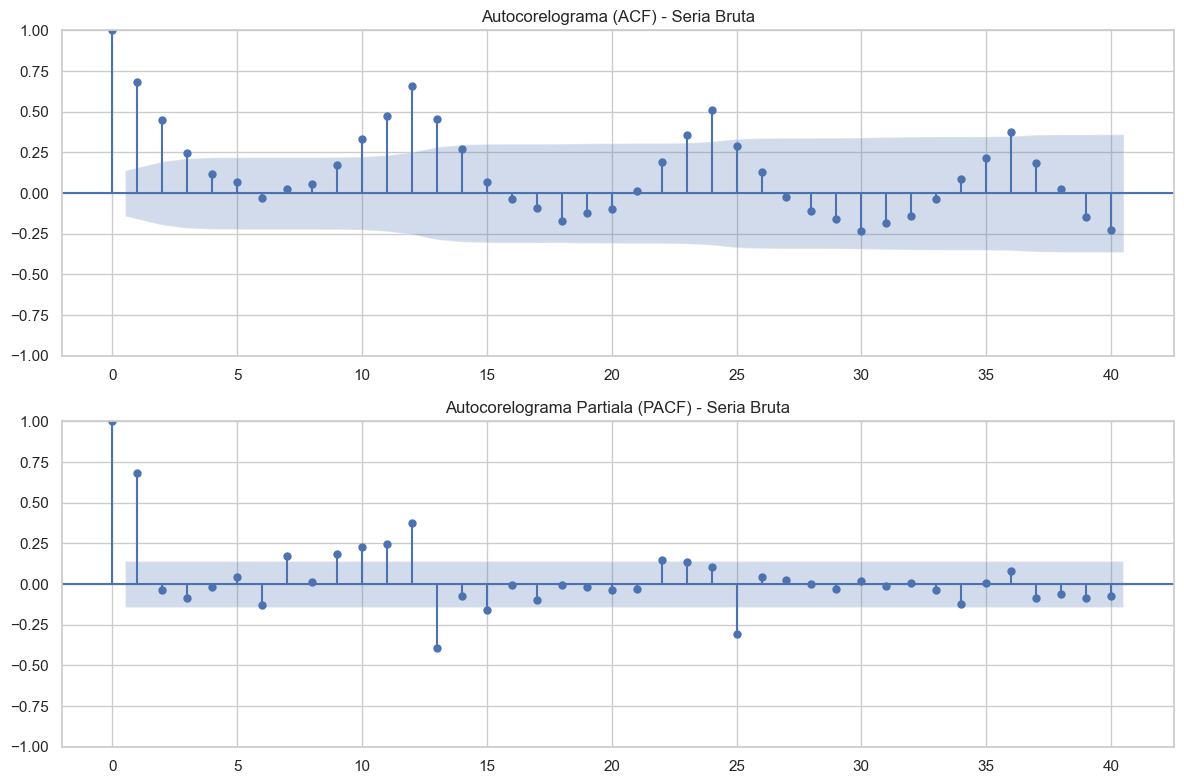

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(df['Consum_Energie_GWh'].dropna(), ax=axes[0], lags=40)
axes[0].set_title('Autocorelograma (ACF) - Seria Bruta')

# PACF
plot_pacf(df['Consum_Energie_GWh'].dropna(), ax=axes[1], lags=40, method='ywm')
axes[1].set_title('Autocorelograma Partiala (PACF) - Seria Bruta')

plt.tight_layout()
plt.show()

In [110]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
warnings.filterwarnings("ignore")

def check_stationarity(series, name):
    print(f"--- Teste de Stationaritate pentru {name} ---")

    # ADF Test
    adf_res = adfuller(series)
    print(f"ADF p-value: {adf_res[1]:.4f}")

    # KPSS Test
    kpss_res = kpss(series, regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_res[1]:.4f}")

    # Logica de decizie
    if adf_res[1] < 0.05 and kpss_res[1] > 0.05:
        print("Concluzie: Seria este STATIONARA.\n")
    else:
        print("Concluzie: Seria este NESTATIONARA (necesita diferentiere).\n")

# 2. Testarea seriei diferențiate (prima diferență)
consum_diff = df['Consum_Energie_GWh'].diff().dropna()
check_stationarity(consum_diff, "Consum Energie (Prima Diferenta)")

--- Teste de Stationaritate pentru Consum Energie (Prima Diferenta) ---
ADF p-value: 0.0028
KPSS p-value: 0.1000
Concluzie: Seria este STATIONARA.



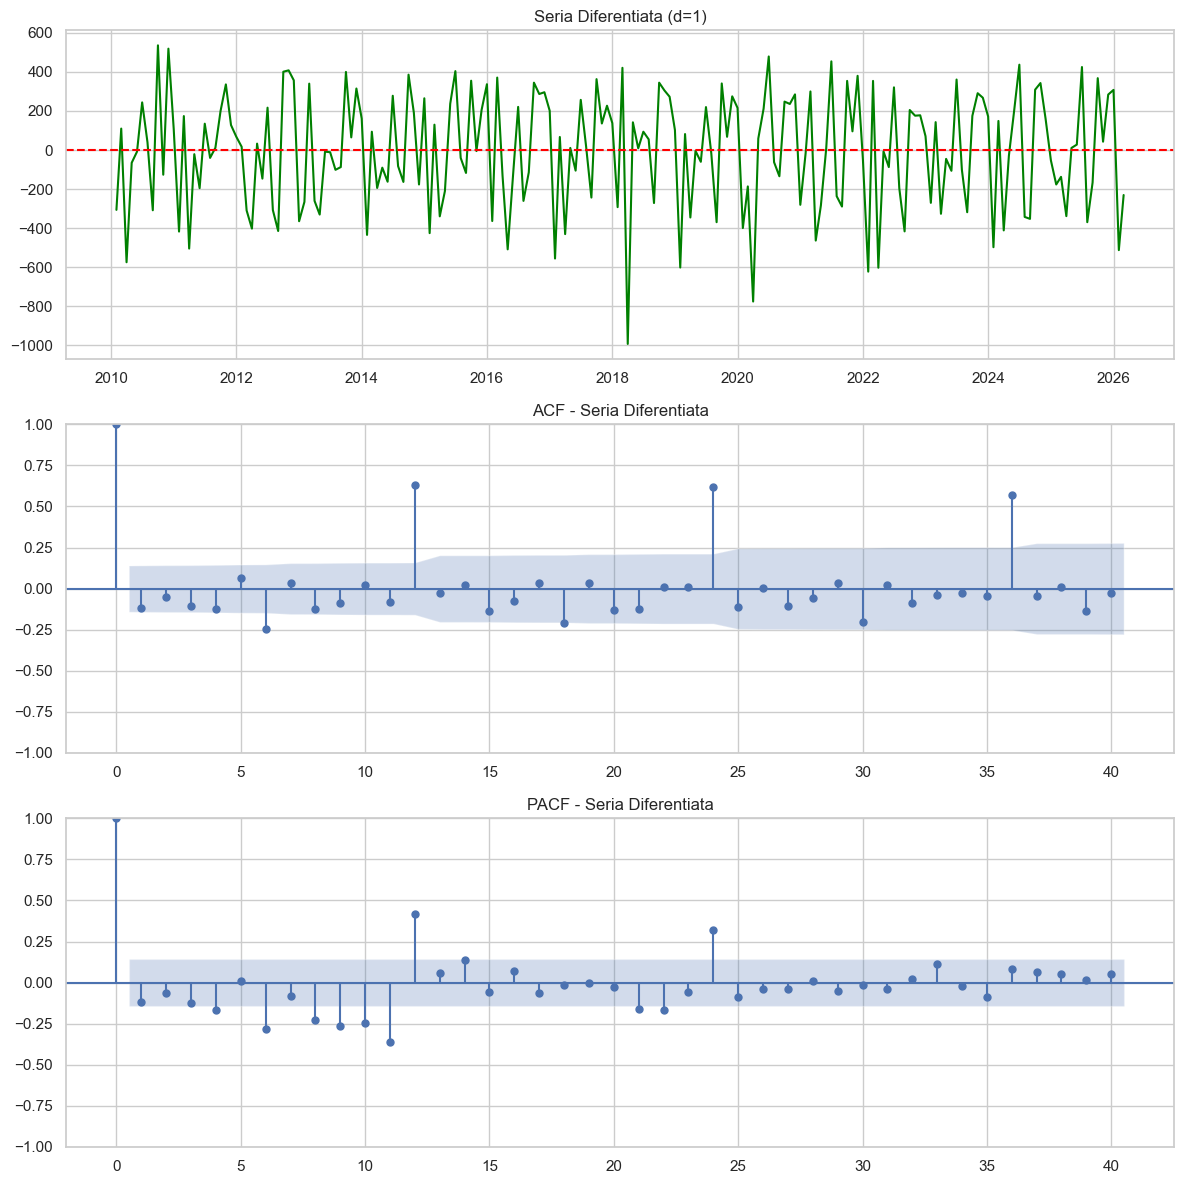

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calculam seria diferentiata (d=1)
# Eliminăm primul rand care devine NaN
df_diff = df['Consum_Energie_GWh'].diff().dropna()

# 2. Vizualizare: Seria diferentiata, ACF și PACF
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot Seria Diferentiata
axes[0].plot(df_diff, color='green')
axes[0].set_title('Seria Diferentiata (d=1)')
axes[0].axhline(0, color='red', linestyle='--') # Linia mediana

# Plot ACF
plot_acf(df_diff, ax=axes[1], lags=40)
axes[1].set_title('ACF - Seria Diferentiata')

# Plot PACF
plot_pacf(df_diff, ax=axes[2], lags=40, method='ywm')
axes[2].set_title('PACF - Seria Diferentiata')

plt.tight_layout()
plt.show()

SAR: 2

SMA: 3

AR: max 1

MA: max 1

In [ ]:
import pmdarima as pm

model_sarima = pm.auto_arima(train, 
                      d=1,                # Diferentiere simpla
                      D=0,                
                      m=12,               # Frecventa lunara
                      
                      # Limite nesezoniere (AR maxim 1, MA maxim 1)
                      start_p=0, max_p=1,
                      start_q=0, max_q=1,
                      
                      # Limite sezoniere (SAR maxim 2, SMA maxim 3)
                      start_P=0, max_P=2,
                      start_Q=0, max_Q=3,
                      
                      seasonal=True,
                      trace=True,         # Vedem cum cauta
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)

print(model_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2414.596, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2321.140, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2365.264, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2412.613, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2413.028, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2289.411, Time=0.42 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.16 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=2294.397, Time=0.44 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=2284.764, Time=0.37 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2317.970, Time=0.15 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=2257.598, Time=0.79 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : 

Modelul selectat este  SARIMA(0,1,1)(2,0,1)

Conform testului Ljung_Box nu am autocorelare in reziduuri.

Conform testului Jarque Bera teoretic nu am reziduuri normal distribuite, dar as putea spune ca am o distributia aproape normal distribuita, ea fiind usor leptokurtica.

Conform testului de heteroscedasticitate nu am reziduuri heteroscedastice, ele fiind homoscedastice, deci au varianta constanta.

--- Tabel Metrici Model ---
          Model Castigator
MAE             226.271525
MAPE (%)          5.281349
MASE              0.946719
RMSE            256.894210
AIC            2257.598030
BIC            2276.412821


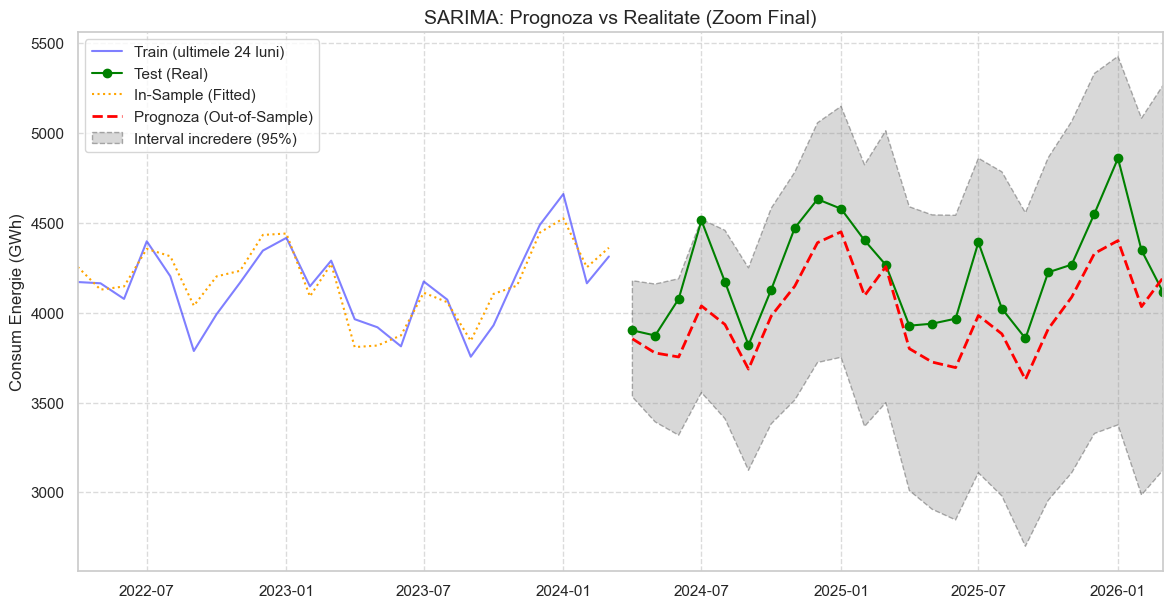

In [112]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prognoza Out-of-sample (pe setul de test)
forecast_values, conf_int = model_sarima.predict(n_periods=len(test), return_conf_int=True)
forecast_series = pd.Series(forecast_values, index=test.index)
conf_int_df = pd.DataFrame(conf_int, index=test.index, columns=['lower', 'upper'])

# 2. Fitted values In-sample (pentru a vedea cum a invatat pe train)
in_sample_preds = model_sarima.predict_in_sample()
in_sample_series = pd.Series(in_sample_preds, index=train.index)

# 3. Calcul Metricilor
mae = mean_absolute_error(test, forecast_series)
rmse = np.sqrt(mean_squared_error(test, forecast_series))
mape = np.mean(np.abs((test - forecast_series) / test)) * 100

# MASE (Mean Absolute Scaled Error)
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase = mae / naive_mae_train

metrics = {
    "MAE": mae,
    "MAPE (%)": mape,
    "MASE": mase,
    "RMSE": rmse,
    "AIC": model_sarima.aic(),
    "BIC": model_sarima.bic()
}

df_metrics = pd.DataFrame(metrics, index=["Model Castigator"])
print("--- Tabel Metrici Model ---")
print(df_metrics.T)

# 4. Vizualizare cu Zoom și Stilizat
plt.figure(figsize=(14, 7))

# Plot train (doar ultimul segment de 24 luni pentru claritate)
# Ajusteaza indexul dacă train e prea scurt
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)

# Plot in-sample (fitted) și out-of-sample (forecast)
plt.plot(in_sample_series.loc[zoom_start:].index, in_sample_series.loc[zoom_start:], label='In-Sample (Fitted)', color='orange', linestyle=':')
plt.plot(forecast_series.index, forecast_series, label='Prognoza (Out-of-Sample)', color='red', linestyle='--', linewidth=2)

# Plot interval de încredere stilizat (Gri cu margine)
plt.fill_between(conf_int_df.index, conf_int_df['lower'], conf_int_df['upper'], 
                 color='gray', alpha=0.3, label='Interval incredere (95%)',
                 edgecolor='black', linestyle='--')

# Setări zoom și formatare
plt.xlim(zoom_start, zoom_end)
plt.title('SARIMA: Prognoza vs Realitate (Zoom Final)', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.show()

In [113]:
from statsmodels.stats.diagnostic import het_arch

# Aplicam testul Engle (Lagrange Multiplier)
# Rezultatul confirmă (sau infirma) daca ai nevoie de GARCH
lm_stat, p_value, f_stat, f_p_value = het_arch(model_sarima.resid(), nlags=12)

print(f"Test Engle (LM Test pentru ARCH): p-value = {p_value:.4f}")

if p_value > 0.05:
    print("Nu exista efecte ARCH. Nu este necesar un model GARCH.")
else:
    print("Exista efecte ARCH! Aici ar trebui un model GARCH.")

Test Engle (LM Test pentru ARCH): p-value = 0.7388
Nu exista efecte ARCH. Nu este necesar un model GARCH.


--- Tabel Metrici Holt-Winters ---
          Holt-Winters (ETS)
MAE               197.035007
MAPE (%)            4.612506
MASE                0.824394
RMSE              229.501341
AIC              1747.261972
BIC              1797.528589


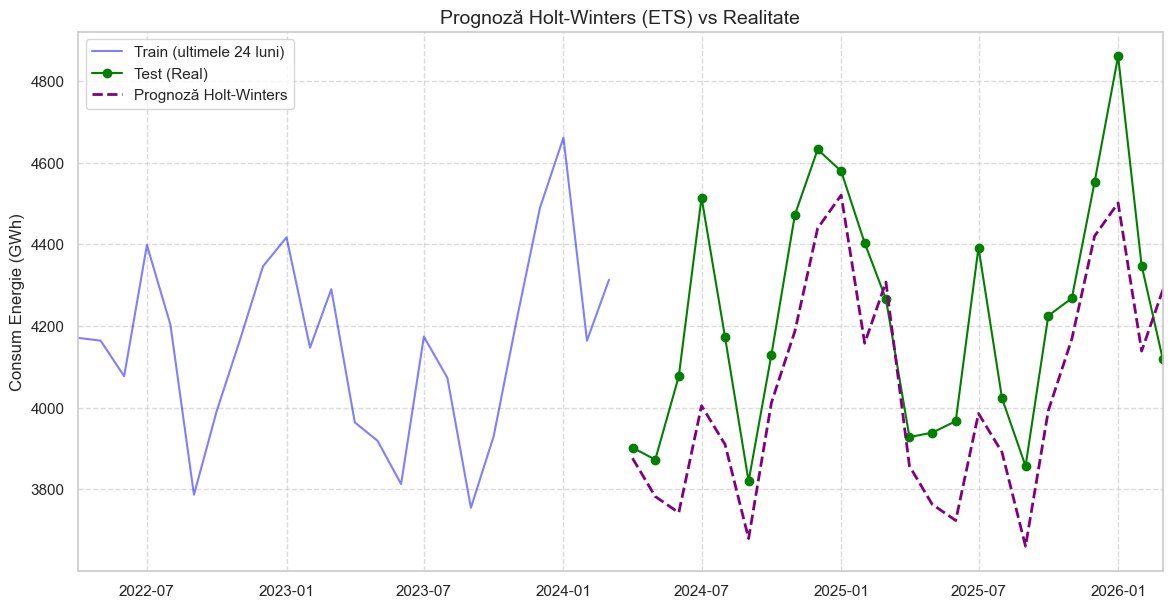

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Inițializare și Fit model Holt-Winters
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()

# 2. Prognoză pe setul de test
hw_forecast = hw_model.forecast(steps=len(test))
hw_forecast_series = pd.Series(hw_forecast, index=test.index)

# 3. Calcul Metricilor
mae_hw = mean_absolute_error(test, hw_forecast_series)
rmse_hw = np.sqrt(mean_squared_error(test, hw_forecast_series))
mape_hw = np.mean(np.abs((test - hw_forecast_series) / test)) * 100

# MASE
naive_mae_train = np.mean(np.abs(train.diff().dropna()))
mase_hw = mae_hw / naive_mae_train

# Adăugare AIC și BIC
metrics_hw = {
    "MAE": mae_hw,
    "MAPE (%)": mape_hw,
    "MASE": mase_hw,
    "RMSE": rmse_hw,
    "AIC": hw_model.aic,
    "BIC": hw_model.bic
}

df_metrics_hw = pd.DataFrame(metrics_hw, index=["Holt-Winters (ETS)"])
print("--- Tabel Metrici Holt-Winters ---")
print(df_metrics_hw.T)

# 4. Vizualizare (Zoom pe ultimele 24 luni + test)
zoom_start = train.index[-24] 
zoom_end = test.index[-1]

plt.figure(figsize=(14, 7))

plt.plot(train.loc[zoom_start:].index, train.loc[zoom_start:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Test (Real)', color='green', marker='o', markersize=6)
plt.plot(hw_forecast_series.index, hw_forecast_series, label='Prognoză Holt-Winters', color='purple', linestyle='--', linewidth=2)

# Setări grafic
plt.xlim(zoom_start, zoom_end)
plt.title('Prognoză Holt-Winters (ETS) vs Realitate', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

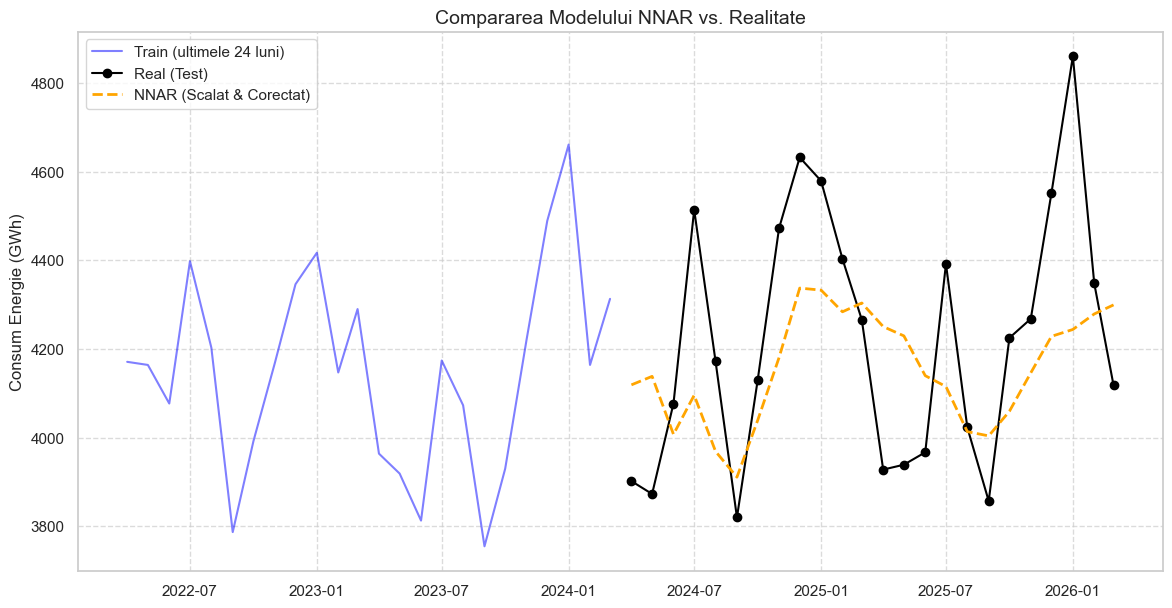

In [115]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 0. INITIALIZARE SI SCALARE DATE
# ==========================================
# Initializam scaler-ul doar pe datele de TRAIN pentru a evita "data leakage"
scaler = MinMaxScaler(feature_range=(0, 1))

# Transformam train si test in array-uri 2D pentru scaler
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

# Convertim inapoi in Pandas Series pentru a pastra consistenta scriptului tau
train_scaled_series = pd.Series(train_scaled, index=train.index)

# ==========================================
# 1. Pregatire date (cream lag-uri din datele scalate)
# ==========================================
def create_lags(data, lags=12):
    df_lags = pd.concat([data.shift(i) for i in range(1, lags + 1)], axis=1)
    df_lags.columns = [f'lag_{i}' for i in range(1, lags + 1)]
    return df_lags.dropna(), data.iloc[lags:]

# Rulam functia pe seria scalata!
X_train, y_train = create_lags(train_scaled_series, lags=12)

# ==========================================
# 2. Model NNAR (MLP)
# ==========================================
nnar_model = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=2000, random_state=42)
nnar_model.fit(X_train, y_train)

# ==========================================
# 3. Prognoza recursiva (Totul se intampla SCALAT)
# ==========================================
# Plecam de la ultimele 12 valori din TRAIN SCALAT
input_seq = train_scaled[-12:].tolist()
nnar_forecast_scaled = []

for _ in range(len(test)):
    # Predictia generata va fi o valoare intre 0 si 1
    pred = nnar_model.predict(np.array(input_seq[-12:]).reshape(1, -1))[0]
    nnar_forecast_scaled.append(pred)
    input_seq.append(pred) # Adaugam valoarea scalata in istoric pentru pasul urmator

# Transformam predictiile scalate inapoi in unitatea originala (GWh) 
nnar_forecast_rescaled = scaler.inverse_transform(np.array(nnar_forecast_scaled).reshape(-1, 1)).flatten()
nnar_forecast_series = pd.Series(nnar_forecast_rescaled, index=test.index)

# ==========================================
# 4. Metricile pentru NNAR (calculate pe valorile reale, in GWh)
# ==========================================
mae_nnar = mean_absolute_error(test, nnar_forecast_series)
rmse_nnar = np.sqrt(mean_squared_error(test, nnar_forecast_series))
mape_nnar = np.mean(np.abs((test - nnar_forecast_series) / test)) * 100
mase_nnar = mae_nnar / naive_mae_train # naive_mae_train definit anterior

# ==========================================
# 5. Vizualizare Comparativa (Include istoric din Train vs NNAR)
# ==========================================
plt.figure(figsize=(14, 7))

plt.plot(train.index[-24:], train.iloc[-24:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)
plt.plot(test.index, test, label='Real (Test)', color='black', marker='o')
plt.plot(test.index, nnar_forecast_series, label='NNAR (Scalat & Corectat)', color='orange', linestyle='--', linewidth=2)

plt.title('Compararea Modelului NNAR vs. Realitate', fontsize=14)
plt.ylabel('Consum Energie (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- TABEL COMPARATIV FINAL: Acuratete Modele ---
                           MAE  MAPE (%)      MASE        RMSE
SARIMA              226.271525  5.281349  0.946719  256.894210
Holt-Winters (ETS)  197.035007  4.612506  0.824394  229.501341
NNAR (MLP)          209.997862  4.895832  0.878631  248.626528


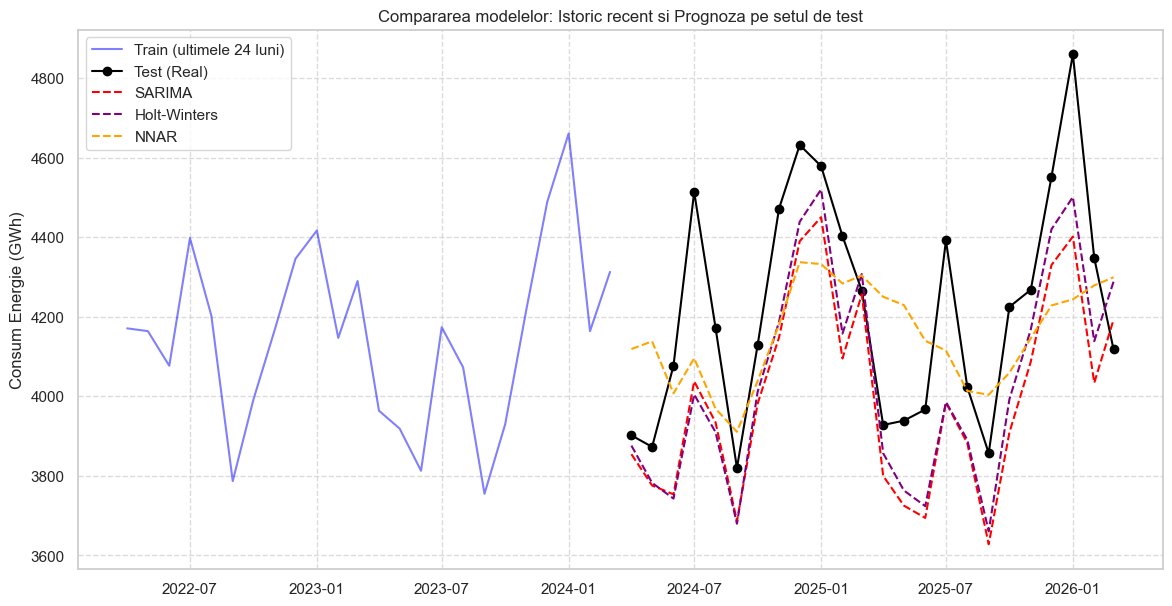

In [114]:
# 5. Tabel Comparativ Final
final_comparison = pd.DataFrame({
    "SARIMA": [mae, mape, mase, rmse],
    "Holt-Winters (ETS)": [mae_hw, mape_hw, mase_hw, rmse_hw],
    "NNAR (MLP)": [mae_nnar, mape_nnar, mase_nnar, rmse_nnar]
}, index=["MAE", "MAPE (%)", "MASE", "RMSE"])

print("--- TABEL COMPARATIV FINAL: Acuratete Modele ---")
print(final_comparison.T)

# 6. Vizualizare Comparativa (Include istoric recent din Train)
plt.figure(figsize=(14, 7))

# Plotam ultimele 24 de luni din Train pentru context vizual
plt.plot(train.index[-24:], train.iloc[-24:], label='Train (ultimele 24 luni)', color='blue', alpha=0.5)

# Plotam setul de Test (Realitatea)
plt.plot(test.index, test, label='Test (Real)', color='black', marker='o')

# Plotam prognozele celor 3 modele
plt.plot(test.index, forecast_series, label='SARIMA', color='red', linestyle='--')
plt.plot(test.index, hw_forecast_series, label='Holt-Winters', color='purple', linestyle='--')
plt.plot(test.index, nnar_forecast_series, label='NNAR', color='orange', linestyle='--')

plt.title('Compararea modelelor: Istoric recent si Prognoza pe setul de test')
plt.ylabel('Consum Energie (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Cel mai bun model conform metricilor MAE,MAPE,MASE si RMSE, unde luam cele mai mici valori, este netezirea exponentiala (H-W).

## Analiza multivariata

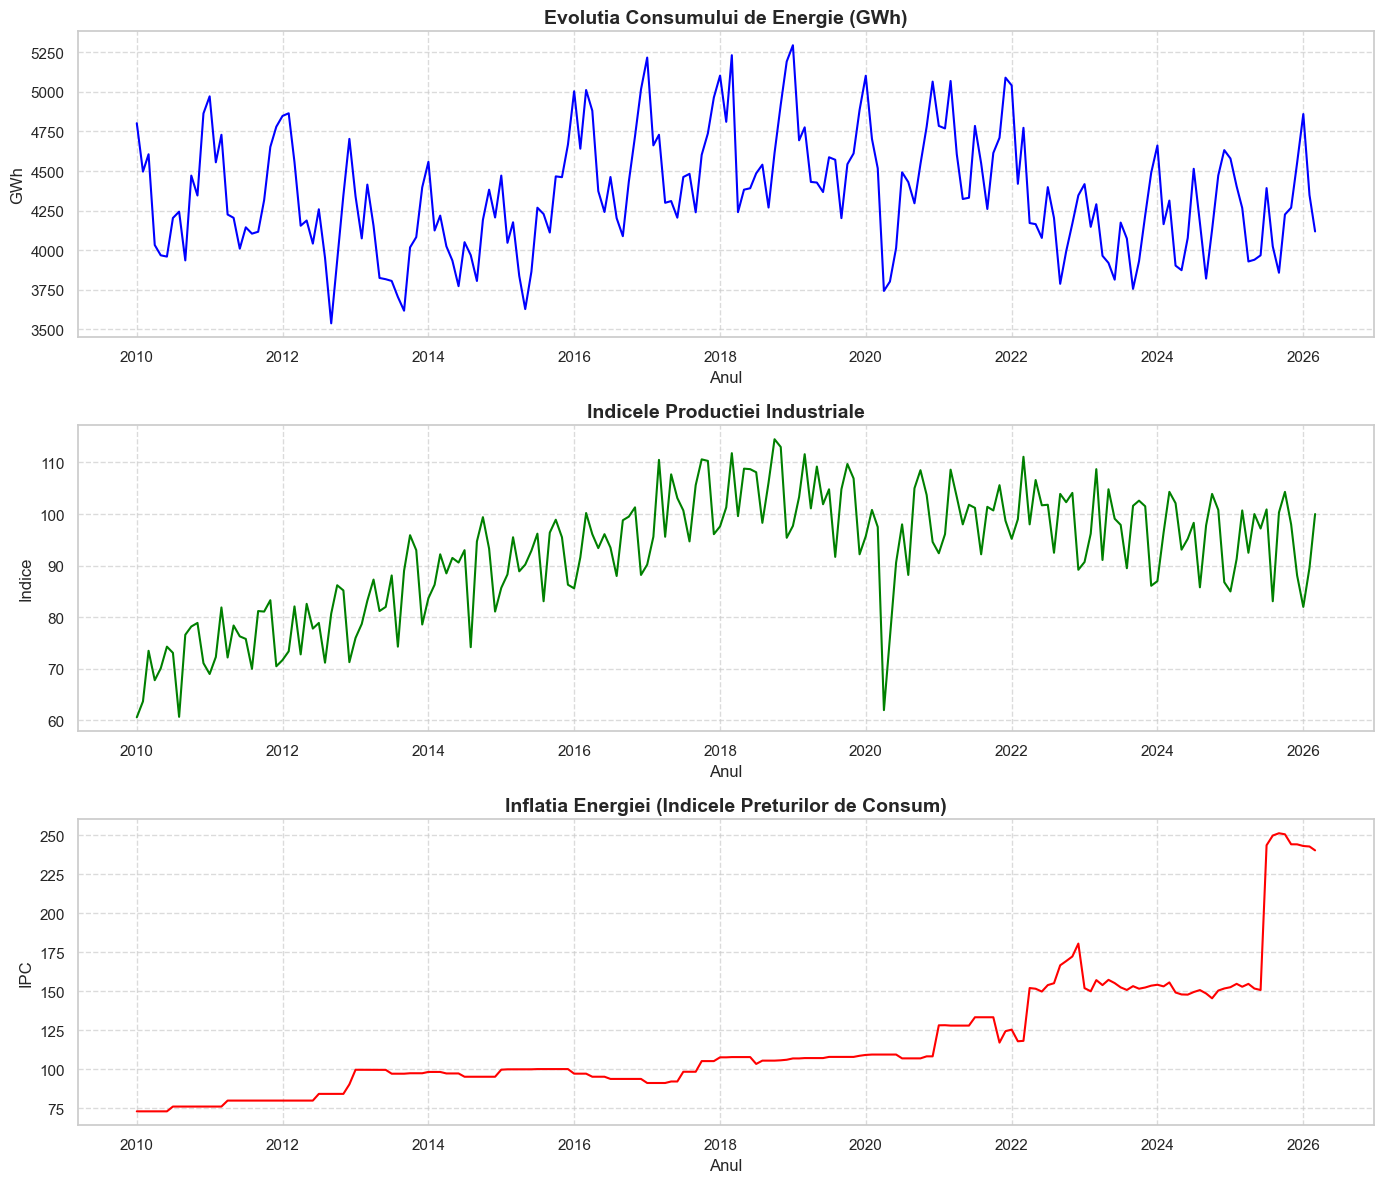

In [120]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Consum de Energie (Seria Ta Principala)
axes[0].plot(df.index, df['Consum_Energie_GWh'], color='blue', linewidth=1.5)
axes[0].set_title('Evolutia Consumului de Energie (GWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('GWh')
axes[0].set_xlabel('Anul')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Productia Industriala
axes[1].plot(df.index, df['Productie_Industriala_Idx'], color='green', linewidth=1.5)
axes[1].set_title('Indicele Productiei Industriale', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Indice')
axes[1].set_xlabel('Anul')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Inflatia Energiei (Pretul)
axes[2].plot(df.index, df['Inflatie_Energie_Ipc'], color='red', linewidth=1.5)
axes[2].set_title('Inflatia Energiei (Indicele Preturilor de Consum)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('IPC')
axes[2].set_xlabel('Anul')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setari generale
plt.tight_layout() # Aseaza graficele frumos, fara sa se suprapuna
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Cream un dataframe nou care va prelua indexul de timp (data) din df-ul vechi
df_log = pd.DataFrame(index=df.index)

# Aplicam logaritmul natural și creăm noile coloane
df_log['Consum_log'] = np.log(df['Consum_Energie_GWh'])
df_log['Productie_log'] = np.log(df['Productie_Industriala_Idx'])
df_log['Inflatie_log'] = np.log(df['Inflatie_Energie_Ipc'])

# Afisam primele 5 randuri ca să ne asiguram ca transformarea a reusit
df_log.head()

,Consum_log,Productie_log,Inflatie_log
date,,,
2010-01-01,8.476788,4.104295,4.290322
2010-02-01,8.410943,4.154185,4.290322
2010-03-01,8.435115,4.297285,4.290322
2010-04-01,8.302018,4.216562,4.290322
2010-05-01,8.285765,4.249923,4.290322


In [18]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.vector_ar.var_model import VAR

# 1. Cream un dataframe nou pentru seriile desezonalizate
df_clean = pd.DataFrame(index=df_log.index)

# Aplicam filtrul STL pentru a extrage sezonalitatea (doar pentru Consum si Productie)
for col in ['Consum_log', 'Productie_log']:
    # period=12 pentru date lunare; robust=True pentru a ignora valorile extreme la calculul trendului
    stl_model = STL(df_log[col], period=12, robust=True)
    rezultat_stl = stl_model.fit()
    
    # Seria curata este seria logaritmată din care scadem componenta sezoniera
    df_clean[col] = df_log[col] - rezultat_stl.seasonal

# Pentru Inflatie, o preluam asa cum e (ea nu are sezonalitate repetitiva)
df_clean['Inflatie_log'] = df_log['Inflatie_log']

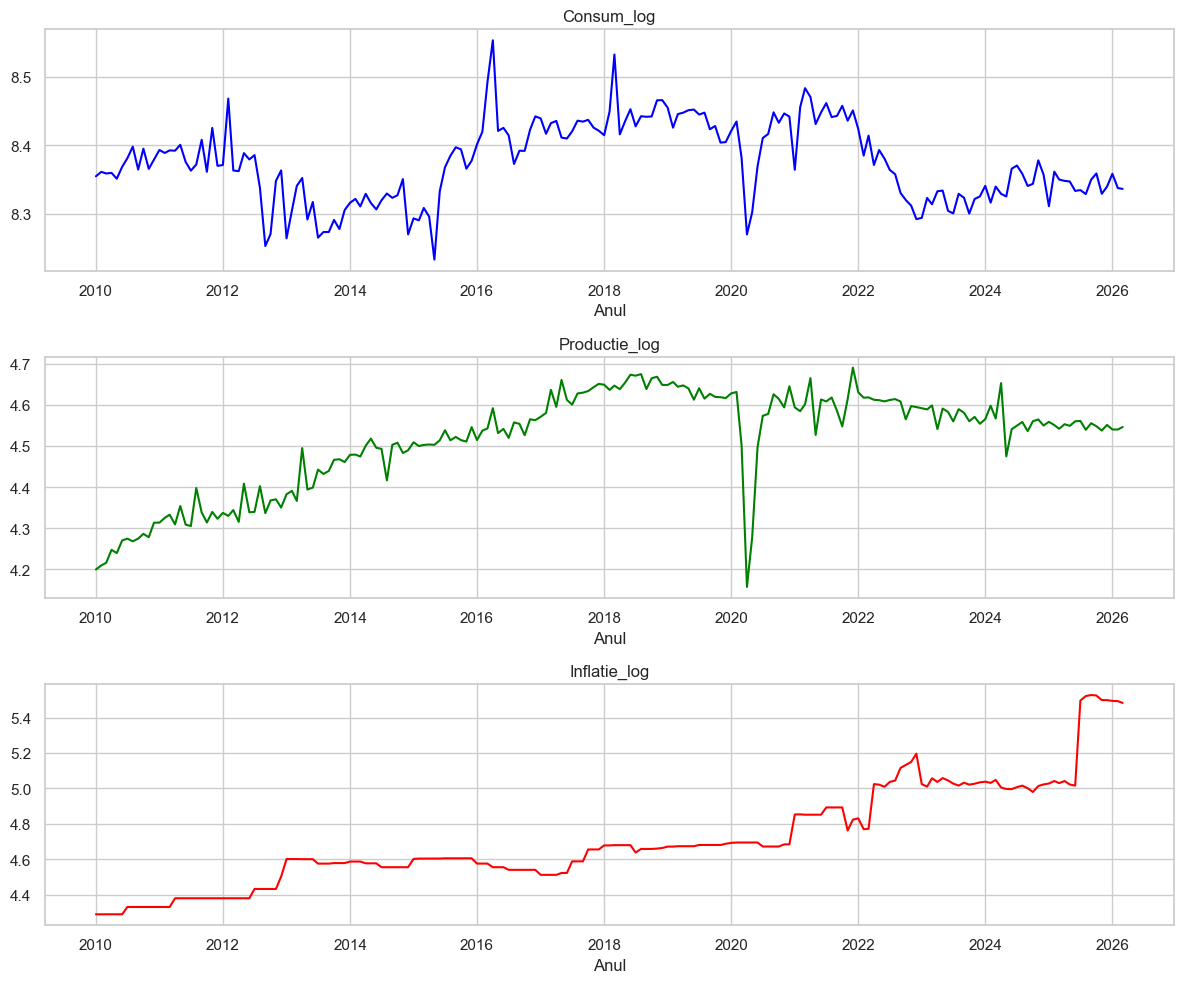

In [123]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(df_clean['Consum_log'], color='blue')
axes[0].set_title('Consum_log')
axes[0].set_xlabel('Anul')

axes[1].plot(df_clean['Productie_log'], color='green')
axes[1].set_title('Productie_log')
axes[1].set_xlabel('Anul')

axes[2].plot(df_clean['Inflatie_log'], color='red')
axes[2].set_title('Inflatie_log')
axes[2].set_xlabel('Anul')

plt.tight_layout()
plt.show()

Am scos componenta sezoniera din variabilele Consum si Indice productie industriala.

In [122]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

def test_stationarity_log(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF
    adf_pvalue = adfuller(series.dropna(), autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Stationara (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-stationara (Acceptam H0)'}")

    # Test KPSS
    kpss_pvalue = kpss(series.dropna(), regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-stationara (Respingem H0)' if kpss_pvalue <= 0.05 else 'Stationara (Acceptam H0)'}")
    print("-" * 40)

# Rulam pe coloanele logaritmate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_log(df_clean[col], title=col)

=== Consum_log ===
ADF p-value:  0.0838 -> Non-stationara (Acceptam H0)
KPSS p-value: 0.1000 -> Stationara (Acceptam H0)
----------------------------------------
=== Productie_log ===
ADF p-value:  0.1149 -> Non-stationara (Acceptam H0)
KPSS p-value: 0.0100 -> Non-stationara (Respingem H0)
----------------------------------------
=== Inflatie_log ===
ADF p-value:  0.9558 -> Non-stationara (Acceptam H0)
KPSS p-value: 0.0100 -> Non-stationara (Respingem H0)
----------------------------------------


In [124]:
# Cream un dataframe nou cu prima diferenta a seriilor logaritmate
# dropna() este obligatoriu pentru că diferentierea pierde primul rand
df_log_diff = df_clean.diff().dropna()

In [126]:
def test_stationarity_diff(series, title=''):
    print(f"=== {title} ===")
    
    # Test ADF (Vrem sa respingem H0)
    adf_pvalue = adfuller(series, autolag='AIC')[1]
    print(f"ADF p-value:  {adf_pvalue:.4f} -> {'Stationara (Respingem H0)' if adf_pvalue <= 0.05 else 'Non-stationara (Acceptam H0)'}")

    # Test KPSS (Vrem sa acceptam H0)
    kpss_pvalue = kpss(series, regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_pvalue:.4f} -> {'Non-stationara (Respingem H0)' if kpss_pvalue <= 0.05 else 'Stationara (Acceptam H0)'}")
    print("-" * 45)

# Rulam testele pe seriile diferentiate
for col in ['Consum_log', 'Productie_log', 'Inflatie_log']:
    test_stationarity_diff(df_log_diff[col], title=col + " (Diferentiata)")

=== Consum_log (Diferentiata) ===
ADF p-value:  0.0000 -> Stationara (Respingem H0)
KPSS p-value: 0.1000 -> Stationara (Acceptam H0)
---------------------------------------------
=== Productie_log (Diferentiata) ===
ADF p-value:  0.0000 -> Stationara (Respingem H0)
KPSS p-value: 0.0869 -> Stationara (Acceptam H0)
---------------------------------------------
=== Inflatie_log (Diferentiata) ===
ADF p-value:  0.0000 -> Stationara (Respingem H0)
KPSS p-value: 0.1000 -> Stationara (Acceptam H0)
---------------------------------------------


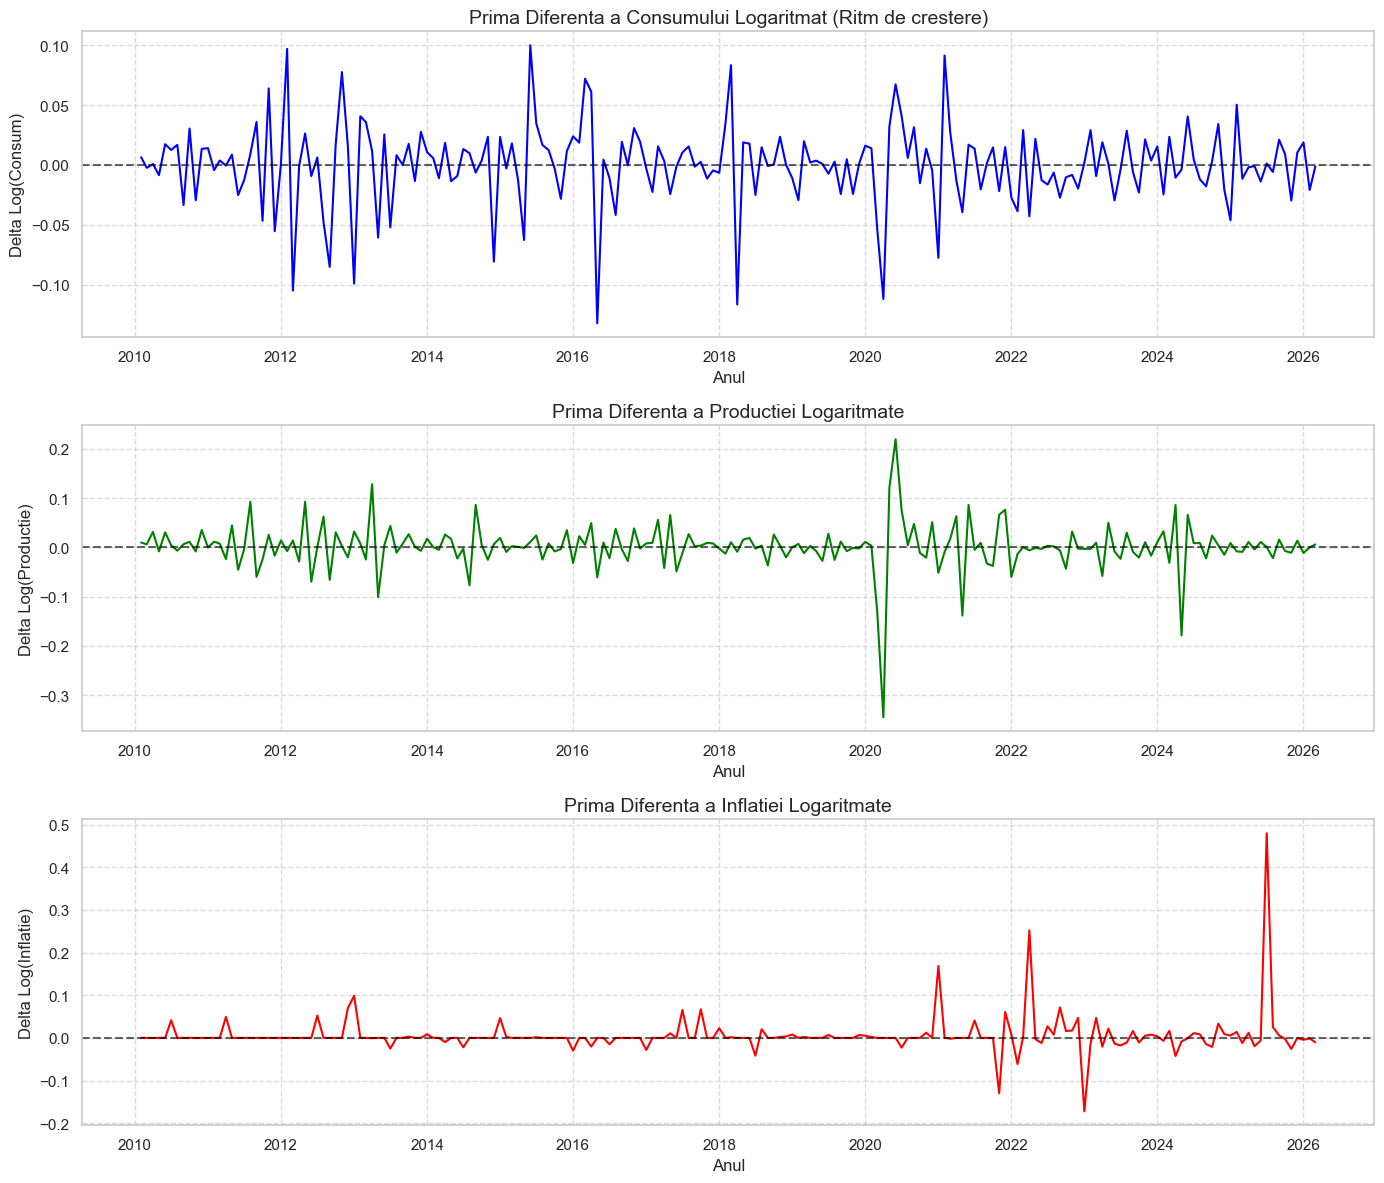

In [127]:
import matplotlib.pyplot as plt

# Cream figura cu 3 grafice suprapuse
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Grafic Consum (Log Diferentiat)
axes[0].plot(df_log_diff.index, df_log_diff['Consum_log'], color='blue', linewidth=1.5)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[0].set_title('Prima Diferenta a Consumului Logaritmat (Ritm de crestere)', fontsize=14)
axes[0].set_ylabel('Delta Log(Consum)')
axes[0].set_xlabel('Anul')
axes[0].grid(True, linestyle='--', alpha=0.7)

# 2. Grafic Productie (Log Diferentiat)
axes[1].plot(df_log_diff.index, df_log_diff['Productie_log'], color='green', linewidth=1.5)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[1].set_title('Prima Diferenta a Productiei Logaritmate', fontsize=14)
axes[1].set_ylabel('Delta Log(Productie)')
axes[1].set_xlabel('Anul')
axes[1].grid(True, linestyle='--', alpha=0.7)

# 3. Grafic Inflatie (Log Diferentiat)
axes[2].plot(df_log_diff.index, df_log_diff['Inflatie_log'], color='red', linewidth=1.5)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.6) # Linia de 0
axes[2].set_title('Prima Diferenta a Inflatiei Logaritmate', fontsize=14)
axes[2].set_ylabel('Delta Log(Inflatie)')
axes[2].set_xlabel('Anul')
axes[2].grid(True, linestyle='--', alpha=0.7)

# Setari generale
plt.tight_layout()
plt.show()

In [128]:
import pandas as pd
import warnings
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")

# 1. Selectam variabilele IN NIVELURI (nediferentiate) din df_clean
df_model = df_clean[['Consum_log', 'Productie_log', 'Inflatie_log']].dropna()
df_model.index = pd.to_datetime(df_model.index)

# 3. Initializam modelul VAR introducand exogenele AICI (la pasul de baza)
model = VAR(df_model)

# 4. Cautam lag-ul optim testand pana la 12 luni
# Acum select_order va rula curat deoarece modelul stie deja de existenta dummy-urilor
lag_results = model.select_order(maxlags=12, trend='c')

# 5. Afisam tabelul cu rezultate pentru disertatie
print("====================== SELECTIE LAG OPTIM  ======================")
print(lag_results.summary())

====================== SELECTIE LAG OPTIM  ======================
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -13.44      -13.39   1.456e-06      -13.42
1      -19.01*     -18.79*  5.575e-09*     -18.92*
2       -18.97      -18.60   5.780e-09      -18.82
3       -18.98      -18.46   5.690e-09      -18.77
4       -18.91      -18.23   6.124e-09      -18.63
5       -18.88      -18.04   6.310e-09      -18.54
6       -18.83      -17.83   6.645e-09      -18.43
7       -18.75      -17.60   7.191e-09      -18.28
8       -18.70      -17.38   7.618e-09      -18.16
9       -18.62      -17.15   8.221e-09      -18.03
10      -18.62      -16.99   8.276e-09      -17.96
11      -18.62      -16.83   8.329e-09      -17.89
12      -18.55      -16.61   8.908e-09      -17.76
--------------------------------------------------


Toate crtieriile indica ca lagul optim este 1.


In [131]:
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Rulam testul Johansen pe datele in nivel (df_clean)
# k_ar_diff = 0 (pentru ca lag-ul VAR ales a fost 1)
johansen_test = coint_johansen(df_clean, det_order=0, k_ar_diff=0)

# Extragem datele exclusiv pentru Tabelul Trace
trace_data = []
for i in range(len(johansen_test.lr1)):
    trace_data.append([
        f"r <= {i}",
        round(johansen_test.lr1[i], 4),    # Statistica Trace
        round(johansen_test.cvt[i, 0], 4), # Critic 90%
        round(johansen_test.cvt[i, 1], 4), # Critic 95%
        round(johansen_test.cvt[i, 2], 4)  # Critic 99%
    ])

df_trace = pd.DataFrame(trace_data, columns=["Ipoteza Nula", "Statistica Trace", "Critic (90%)", "Critic (95%)", "Critic (99%)"])

# Afisam tabelul
print("--- Statistica Trace (Johansen) ---")
print(df_trace.to_string(index=False))

--- Statistica Trace (Johansen) ---
Ipoteza Nula  Statistica Trace  Critic (90%)  Critic (95%)  Critic (99%)
      r <= 0           42.3051       27.0669       29.7961       35.4628
      r <= 1           15.5286       13.4294       15.4943       19.9349
      r <= 2            2.7976        2.7055        3.8415        6.6349


In [132]:
import pandas as pd

# Extragem datele exclusiv pentru Tabelul Maximum Eigenvalue (lr2)
max_eig_data = []
for i in range(len(johansen_test.lr2)):
    max_eig_data.append([
        f"r = {i}",
        round(johansen_test.lr2[i], 4),    # Statistica Max-Eig
        round(johansen_test.cvm[i, 0], 4), # Critic 90%
        round(johansen_test.cvm[i, 1], 4), # Critic 95%
        round(johansen_test.cvm[i, 2], 4)  # Critic 99%
    ])

df_max_eig = pd.DataFrame(max_eig_data, columns=["Ipoteza Nula", "Statistica Max-Eig", "Critic (90%)", "Critic (95%)", "Critic (99%)"])

# Afișăm tabelul
print("--- Statistica Maximum Eigenvalue (Johansen) ---")
print(df_max_eig.to_string(index=False))

--- Statistica Maximum Eigenvalue (Johansen) ---
Ipoteza Nula  Statistica Max-Eig  Critic (90%)  Critic (95%)  Critic (99%)
       r = 0             26.7765       18.8928       21.1314       25.8650
       r = 1             12.7310       12.2971       14.2639       18.5200
       r = 2              2.7976        2.7055        3.8415        6.6349


## VECM

In [133]:
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import VECM

# ==========================================
# ESTIMAREA SI REZUMATUL MODELULUI VECM
# ==========================================

# Folosim exclusiv datele curatate de sezonalitate prin STL
endog_vars = df_clean[['Consum_log', 'Productie_log', 'Inflatie_log']]

# Configurarea modelului (k_ar_diff=0, rank=1 pentru cointegrare)
vecm_model = VECM(endog=endog_vars, 
                  k_ar_diff=0, 
                  coint_rank=1, 
                  deterministic='ci')

# Antrenarea modelului
vecm_res = vecm_model.fit()

# Afisarea output-ului complet
print("====================== REZUMAT MODEL VECM ======================")
print(vecm_res.summary())

====================== REZUMAT MODEL VECM ======================
             Loading coefficients (alpha) for equation Consum_log             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1           -0.2001      0.049     -4.050      0.000      -0.297      -0.103
           Loading coefficients (alpha) for equation Productie_log            
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1            0.1156      0.072      1.606      0.108      -0.025       0.257
            Loading coefficients (alpha) for equation Inflatie_log            
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1           -0.0271      0.072     -0.379      0.705      -0.167

Modelul VECM a fost estimat pe seriile logaritmate, consumul si productia industriala fiind in prealabil desezonalizate utilizand filtrul STL, pentru a izola efectele structurale de zgomotul sezonier de iarna/vara.

### Ecuatia de Cointegrare (Relatia pe termen lung)

Izoland variabila dependenta, ecuatia de echilibru matematic se prezinta astfel:

$$\log(Consum) = 0.4368 \times \log(Productie) - 0.1270 \times \log(Inflatie) + 6.9997$$

Toti coeficientii sunt inalt semnificativi statistic (p-values < 0.01). Deoarece modelul foloseste date logaritmate, acesti coeficienti reprezinta **elasticitati**: pe termen lung, o crestere cu 1% a productiei industriale genereaza o crestere de 0.44% a consumului de energie, in timp ce o scumpire cu 1% a energiei (inflatia) determina o contractie a consumului cu 0.13%.

### Viteza de Ajustare (Termenul de corectie a erorii)

Log-Consumul este singura variabila care echilibreaza piata. Coeficientul sau de ajustare este negativ si inalt semnificativ (-0.2001, p=0.000), indicand faptul ca, in urma unui soc, consumul se ajusteaza pentru a restabili echilibrul cu o viteza de 20.01% pe luna. In schimb, productia si inflatia sunt slab exogene (p-values de 0.108 si 0.705) — ele dicteaza directia pietei pe termen lung, fara a fi fortate sa se corecteze.


In [134]:
test_autocorelare = vecm_res.test_whiteness(nlags=12, adjusted=True)
print("\n--- Testul de Autocorelare a Reziduurilor (Whiteness) ---")
print(test_autocorelare.summary())


--- Testul de Autocorelare a Reziduurilor (Whiteness) ---
Adjusted Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         101.1          129.9   0.589 105
-----------------------------------------


In [103]:
test_norm = vecm_res.test_normality()
print(test_norm.summary())

normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
     2.746e+04          12.59   0.000  6
----------------------------------------


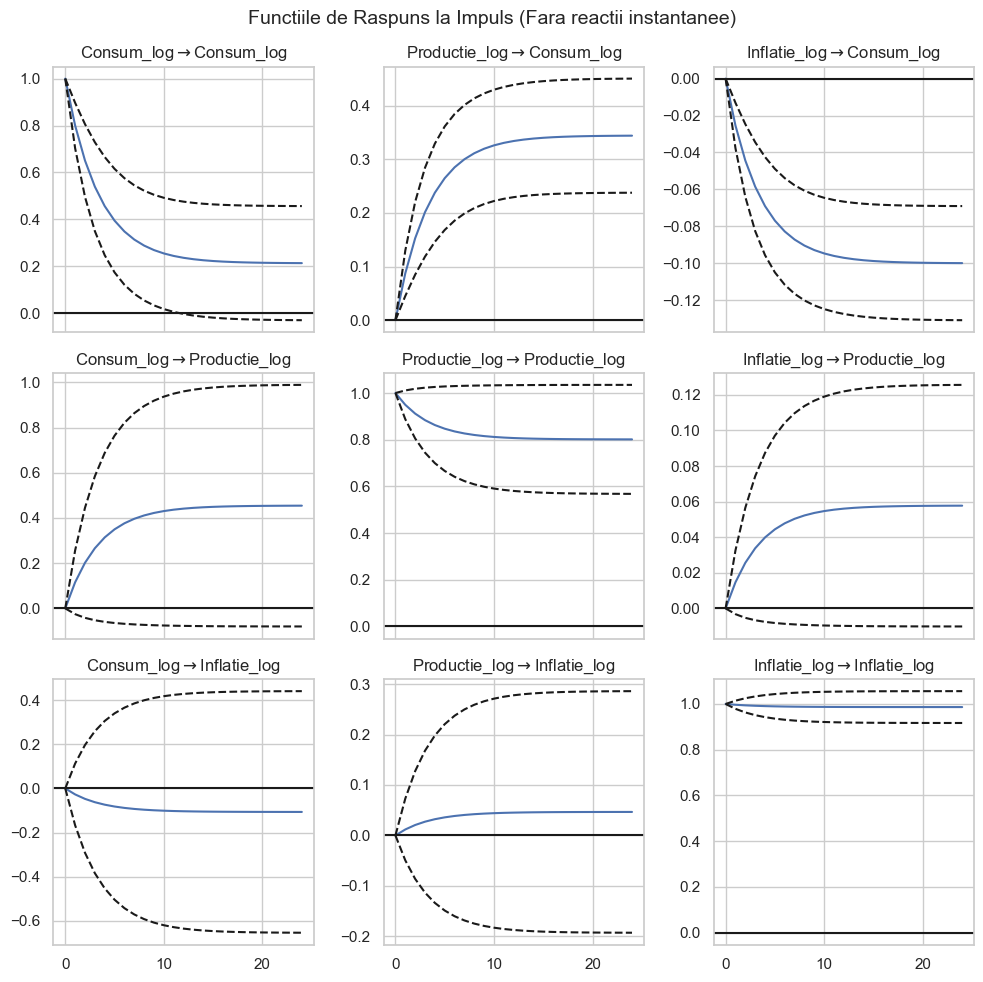

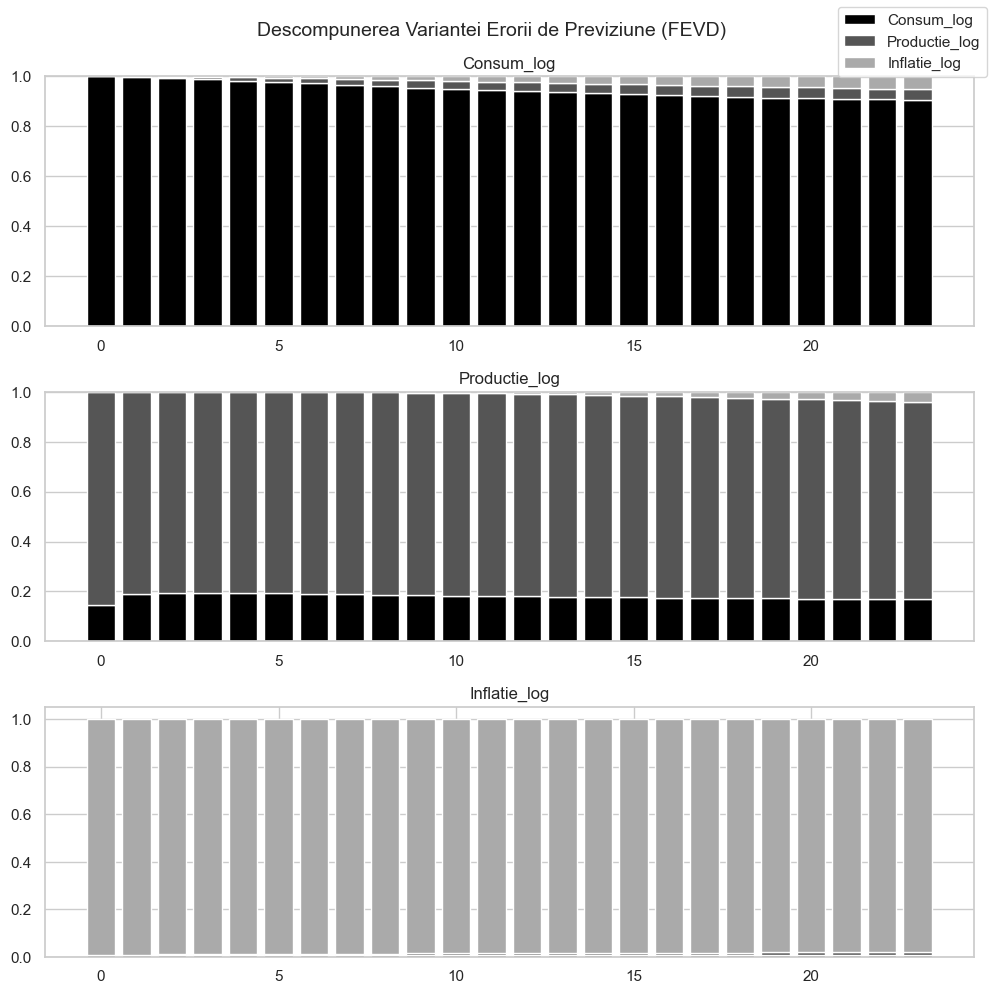


=== Tabel FEVD (Luna 24) ===
FEVD for Consum_log
      Consum_log  Productie_log  Inflatie_log
0       1.000000       0.000000      0.000000
1       0.996241       0.003448      0.000311
2       0.992952       0.005863      0.001184
3       0.988378       0.009168      0.002454
4       0.983255       0.012636      0.004110
5       0.977711       0.016213      0.006075
6       0.971978       0.019729      0.008293
7       0.966215       0.023083      0.010703
8       0.960547       0.026199      0.013254
9       0.955065       0.029034      0.015902
10      0.949828       0.031564      0.018608
11      0.944871       0.033785      0.021344
12      0.940211       0.035706      0.024083
13      0.935848       0.037345      0.026808
14      0.931774       0.038723      0.029503
15      0.927973       0.039869      0.032159
16      0.924425       0.040807      0.034768
17      0.921109       0.041564      0.037326
18      0.918003       0.042167      0.039830
19      0.915084       0.04263

In [135]:
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

import matplotlib.pyplot as plt

# ==========================================
# IRF NECENTRAT (FARA EFECTE INSTANTANEE)
# ==========================================
irf_vecm = vecm_res.irf(periods=24)

# Setand orth=False, fortam toate reactiile incrucisate sa plece din punctul 0
fig_irf = irf_vecm.plot(orth=False, plot_stderr=True)

fig_irf.suptitle('Functiile de Raspuns la Impuls (Fara reactii instantanee)', fontsize=14)
fig_irf.tight_layout()
plt.show()

# ==========================================
# 2. DESCOMPUNEREA VARIANTEI (FEVD) PRIN VAR IN NIVELURI
# Workaround oficial pentru limitarea statsmodels
# ==========================================
# Antrenam un VAR pe datele desezonalizate in nivel, cu lag=2 (echivalent k_ar_diff=1 + 1)
var_nivel_model = VAR(endog_vars)
var_nivel_res = var_nivel_model.fit(2)

# Extragem FEVD-ul pe 24 de luni
fevd_nivel = var_nivel_res.fevd(24)

# Desenam graficul FEVD
fig_fevd = fevd_nivel.plot()
fig_fevd.suptitle('Descompunerea Variantei Erorii de Previziune (FEVD)', fontsize=14)
fig_fevd.tight_layout()
plt.show()

# Afisarea tabelului cu procente brute pentru ultima luna (luna 24)
print("\n=== Tabel FEVD (Luna 24) ===")
print(fevd_nivel.summary())

### Reactia Consumului de Energie

Un soc pe propriul consum genereaza o crestere imediata care se stabilizeaza treptat pe termen lung. Un soc pozitiv in productia industriala determina o crestere gradata si permanenta a consumului de energie. Cresterea inflatiei provoaca o scadere constanta si definitiva a cererii de consum, confirmand relatia inversa dintre pret si volumul cerut.

### Reactia Productiei Industriale

Impactul unui soc din consum asupra productiei este unul de crestere usoara si stabila in timp. Un soc pe propria productie creeaza o crestere imediata care se stabilizeaza la un nivel permanent superior. Socul inflationist genereaza o crestere mica, dar persistenta, a indicelui productiei industriale, indicand o adaptare a sectorului la noile conditii de pret.

### Reactia Inflatiei

Evolutia inflatiei reactioneaza usor negativ la un soc in consumul de energie, stabilizandu-se ulterior la un nivel inferior. Impactul productiei industriale asupra inflatiei este foarte redus, aproape de zero. Un soc asupra propriei inflatii persista la nesfarsit in piata, demonstrand un caracter puternic inertial si faptul ca preturile energiei sunt impuse in mare parte exogen, fara a fi corectate de dinamica interna a celorlalte variabile.


### Descompunerea Variantei pentru Consum

Pe termen lung, variatia consumului este explicata in proportie de 90.5% de propria sa evolutie istorica. Socurile inflationiste contribuie cu 5.1% la modificarea cererii de energie la finalul perioadei analizate, in timp ce influenta productiei industriale este de 4.4%. Aceste rezultate confirma natura inertiala a consumului, care depinde mult mai mult de trecutul sau decat de factorii economici externi.

### Descompunerea Variantei pentru Productie

Dinamica productiei ramane dependenta in proportie de 79.0% de propriile sale socuri structurale. Consumul de energie explica o parte importanta de 16.9% din variatia productiei industriale, indicand o relatie de feedback intre nivelul de activitate industriala si cererea de electricitate. Preturile energiei au un rol marginal, afectand productia in proportie de doar 4.2%.

### Descompunerea Variantei pentru Inflatie

Inflatia se dovedeste a fi o variabila strict exogena, fiind explicata in proportie de 98.1% exclusiv de propria sa evolutie. Productia industriala influenteaza preturile intr-o proportie nesemnificativa de 1.1%, in timp ce consumul intern de energie are un impact neglijabil de 0.8% asupra formarii inflatiei. Aceasta confirma faptul ca preturile energiei in Romania sunt dictate in principal de factori externi sau politici, fiind in mare parte izolate de dinamica industriala si de consumul intern.

# Deep learning

In [142]:
import random

# Fixăm seed-ul pentru ca PyTorch să nu mai genereze rezultate random la fiecare rulare
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


--- Incepem antrenarea modelului LSTM cu Early Stopping ---
Epoca [10/500], Train Loss: 0.046322, Val Loss: 0.035585
Epoca [20/500], Train Loss: 0.034532, Val Loss: 0.030069
Epoca [30/500], Train Loss: 0.035185, Val Loss: 0.027623
Epoca [40/500], Train Loss: 0.030574, Val Loss: 0.028470
Epoca [50/500], Train Loss: 0.022425, Val Loss: 0.026664
Epoca [60/500], Train Loss: 0.022276, Val Loss: 0.025839
Epoca [70/500], Train Loss: 0.022030, Val Loss: 0.028066
Epoca [77/500], Train Loss: 0.019623, Val Loss: 0.026745

[!] Antrenament oprit timpuriu la epoca 77.
[!] Modelul se intoarce la cea mai buna epoca (Val Loss: 0.025728).

=== PERFORMANTA FINALA LSTM MULTIVARIAT (PyTorch) ===
MAE:  0.0504
RMSE: 0.0647
MAPE: 0.6027%
MASE: 0.9620


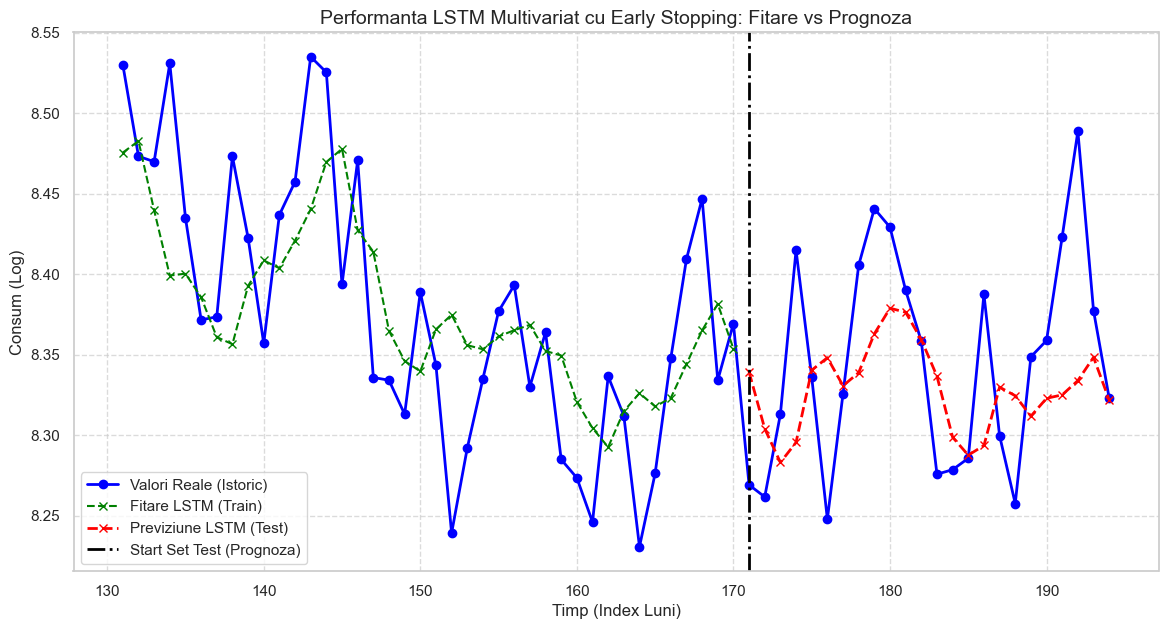

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy

# ==========================================
# 1. PREGATIREA DATELOR
# ==========================================
date_model = df_log[['Consum_log', 'Productie_log', 'Inflatie_log']].values

scaler = MinMaxScaler(feature_range=(0, 1))
date_scalate = scaler.fit_transform(date_model)

def creeaza_secvente(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :]) 
        Y.append(dataset[i + look_back, 0])     
    return np.array(X), np.array(Y)

look_back = 12
X, Y = creeaza_secvente(date_scalate, look_back)

# ==========================================
# 2. DELIMITARE TRAINING SI TEST SET
# ==========================================
dimensiune_test = 24
split_idx = len(X) - dimensiune_test

X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1)

train_data = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_data, batch_size=16, shuffle=False)

# ==========================================
# 3. CONSTRUIREA ARHITECTURII LSTM
# ==========================================
class LSTMMultivariat(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMMultivariat, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        out = self.fc(out[:, -1, :]) 
        return out

model_lstm = LSTMMultivariat(input_size=3, hidden_size=50, num_layers=1, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# ==========================================
# 4. ANTRENAREA MODELULUI CU EARLY STOPPING
# ==========================================
print("\n--- Incepem antrenarea modelului LSTM cu Early Stopping ---")

epochs = 500
patience = 15
patience_counter = 0
best_val_loss = float('inf')
best_model_weights = None

for epoch in range(epochs):
    model_lstm.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model_lstm(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    
    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_test_tensor)
        val_loss = criterion(val_outputs, Y_test_tensor).item()
        
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model_lstm.state_dict())
    else:
        patience_counter += 1
        
    if (epoch + 1) % 10 == 0 or patience_counter >= patience:
        print(f'Epoca [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
        
    if patience_counter >= patience:
        print(f'\n[!] Antrenament oprit timpuriu la epoca {epoch+1}.')
        print(f'[!] Modelul se intoarce la cea mai buna epoca (Val Loss: {best_val_loss:.6f}).')
        break

model_lstm.load_state_dict(best_model_weights)

# ==========================================
# 5. PREVIZIUNE (Pe Test si pe o portiune de Train)
# ==========================================
luni_train_vizibile = 40 

model_lstm.eval() 
with torch.no_grad(): 
    predictii_test_scalate = model_lstm(X_test_tensor).numpy()
    predictii_train_scalate = model_lstm(X_train_tensor[-luni_train_vizibile:]).numpy()

dummy_pred_test = np.zeros((len(predictii_test_scalate), 3))
dummy_pred_test[:, 0] = predictii_test_scalate[:, 0]
predictii_reale_test = scaler.inverse_transform(dummy_pred_test)[:, 0]

dummy_pred_train = np.zeros((len(predictii_train_scalate), 3))
dummy_pred_train[:, 0] = predictii_train_scalate[:, 0]
predictii_reale_train = scaler.inverse_transform(dummy_pred_train)[:, 0]

dummy_test = np.zeros((len(Y_test), 3))
dummy_test[:, 0] = Y_test.reshape(-1)
valori_reale_test = scaler.inverse_transform(dummy_test)[:, 0]

# ==========================================
# 6. EVALUAREA PERFORMANTEI (Calculata STRICT pe Test Set)
# ==========================================
mae_lstm = mean_absolute_error(valori_reale_test, predictii_reale_test)
rmse_lstm = np.sqrt(mean_squared_error(valori_reale_test, predictii_reale_test))
mape_lstm = np.mean(np.abs((valori_reale_test - predictii_reale_test) / valori_reale_test)) * 100

# --- CALCUL MASE (Mean Absolute Scaled Error) ---
valori_reale_train = date_model[:-dimensiune_test, 0]
m = 12
mae_naiv_sezonier = np.mean(np.abs(valori_reale_train[m:] - valori_reale_train[:-m]))
mase_lstm = mae_lstm / mae_naiv_sezonier

print("\n=== PERFORMANTA FINALA LSTM MULTIVARIAT (PyTorch) ===")
print(f"MAE:  {mae_lstm:.4f}")
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAPE: {mape_lstm:.4f}%")
print(f"MASE: {mase_lstm:.4f}")

# ==========================================
# 7. REPREZENTARE GRAFICA EXTINSA (Train + Test)
# ==========================================
plt.figure(figsize=(14, 7))

total_luni = dimensiune_test + luni_train_vizibile
index_timp_total = range(len(df_log) - total_luni, len(df_log))
index_timp_train = range(len(df_log) - total_luni, len(df_log) - dimensiune_test)
index_timp_test = range(len(df_log) - dimensiune_test, len(df_log))

valori_reale_totale = date_model[-total_luni:, 0]

plt.plot(index_timp_total, valori_reale_totale, label='Valori Reale (Istoric)', color='blue', marker='o', linewidth=2)
plt.plot(index_timp_train, predictii_reale_train, label='Fitare LSTM (Train)', color='green', linestyle='dashed', marker='x')
plt.plot(index_timp_test, predictii_reale_test, label='Previziune LSTM (Test)', color='red', linestyle='dashed', marker='x', linewidth=2)

plt.axvline(x=index_timp_test[0], color='black', linestyle='-.', linewidth=2, label='Start Set Test (Prognoza)')

plt.title('Performanta LSTM Multivariat cu Early Stopping: Fitare vs Prognoza', fontsize=14)
plt.xlabel('Timp (Index Luni)', fontsize=12)
plt.ylabel('Consum (Log)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Oprirea timpurie la epoca 77 a prevenit cu succes fenomenul de overfitting. Modelul capteaza corect tendinta principala a consumului si netezeste deliberat extremele pentru a pastra o capacitate ridicata de generalizare pe date necunoscute. Aceasta stabilitate este confirmata pe setul de testare de o eroare medie absoluta de 0.0504 si un MAPE sub 1 procent. In concluzie reteaua LSTM invata eficient interdependentele macroeconomice reale si ofera o predictie robusta fara sa memoreze zgomotul haotic al pietei.